In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Task-1a. Load and visualize the waveform of the first 20 second of speech sample.

Original sampling Rate: 22050 Hz
Processed Audio loaded: Sample rate = 16000 Hz, Duration = 4.50 seconds


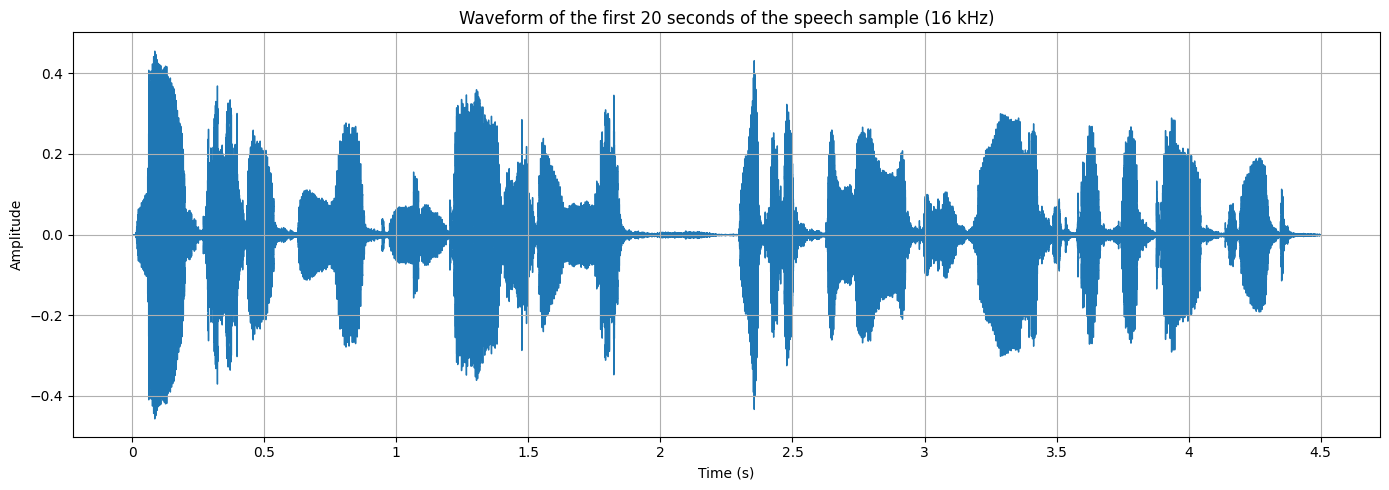

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_file_path = '/content/drive/MyDrive/SpeechProcessing/Lab4/audio.wav'

# Define the target sampling rate
target_sr = 16000 # Hz

try:
    # Load the audio file at its original sampling rate to determine it
    y_original, original_sr = librosa.load(audio_file_path, sr=None)
    print(f"Original sampling Rate: {original_sr} Hz")

    # Resample the audio if the original sampling rate is not already the target_sr
    if original_sr != target_sr:
        y = librosa.resample(y=y_original, orig_sr=original_sr, target_sr=target_sr)
        sr = target_sr # The new sampling rate is the target_sr
    else:
        y = y_original # No resampling needed
        sr = original_sr

    print(f"Processed Audio loaded: Sample rate = {sr} Hz, Duration = {len(y)/sr:.2f} seconds")

except Exception as e:
    print(f"Error loading audio file: {e}")
    y = None
    sr = None

if y is not None and sr is not None:
    # Extract the first 20 seconds of the speech sample
    duration_to_extract = 20 # seconds
    samples_to_extract = int(duration_to_extract * sr)
    y_20s = y[:samples_to_extract]

    # Visualize the waveform
    plt.figure(figsize=(14, 5))
    librosa.display.waveshow(y_20s, sr=sr)
    plt.title('Waveform of the first 20 seconds of the speech sample (16 kHz)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Could not process audio. Please ensure the file path is correct and the file is accessible.")


Task-1b: Compute the total number of frames for a given frame length of 25ms and frame shift of 10ms.

In [ ]:
# Define frame parameters in milliseconds
frame_length_ms = 25  # ms
frame_shift_ms = 10   # ms

# Convert frame parameters from milliseconds to samples
frame_length_samples = int(sr * frame_length_ms / 1000)
frame_shift_samples = int(sr * frame_shift_ms / 1000)

print(f"Frame length: {frame_length_ms} ms ({frame_length_samples} samples)")
print(f"Frame shift: {frame_shift_ms} ms ({frame_shift_samples} samples)")

# Calculate the total number of frames
# The formula is (total_samples - frame_length_samples) / frame_shift_samples + 1
# We use the length of the *full* processed audio signal (y), not just the 20s segment
if len(y) >= frame_length_samples:
    num_frames = int((len(y) - frame_length_samples) / frame_shift_samples) + 1
    print(f"Total number of samples in audio: {len(y)}")
    print(f"Total number of frames: {num_frames}")
else:
    print("Error: Audio signal is shorter than the specified frame length.")


Frame length: 25 ms (400 samples)
Frame shift: 10 ms (160 samples)
Total number of samples in audio: 72003
Total number of frames: 448


Task-1c: Segment the speech signal into overlapping frames using the calculated parameters.

In [ ]:
# Segment the speech signal into overlapping frames
# librosa.util.frame is a convenient function for this purpose
frames = librosa.util.frame(y, frame_length=frame_length_samples, hop_length=frame_shift_samples)

print(f"Shape of frames: {frames.shape}")
print(f"Number of frames: {frames.shape[1]}")
print(f"Length of each frame (samples): {frames.shape[0]}")




Shape of frames: (400, 448)
Number of frames: 448
Length of each frame (samples): 400


Task-1d: Using Hamming window, extract the following time-domain features frame-wise:
• Short-Time Energy (STE)
• Short-Time Magnitude (STM)
• Zero-Crossing Rate (ZCR)
• Autocorrelation
• AMDF
• AMSDF

Apply a Hamming window to each frame to prepare for feature extraction, which helps to reduce spectral leakage.


In [ ]:
import numpy as np

# 1. Generate a Hamming window
hamming_window = np.hamming(frame_length_samples)
print(f"Shape of Hamming window: {hamming_window.shape}")

# 2. Apply the hamming_window to each frame in the frames array
# This performs element-wise multiplication for each column (frame)
windowed_frames = frames * hamming_window[:, np.newaxis]

# 3. Print the shape of the windowed_frames
print(f"Shape of windowed frames: {windowed_frames.shape}")

Shape of Hamming window: (400,)
Shape of windowed frames: (400, 448)


In [ ]:
STE = np.sum(windowed_frames**2, axis=0)

print(f"Shape of Short-Time Energy (STE) array: {STE.shape}")
print(f"First 5 STE values: {STE[:5]}")

Shape of Short-Time Energy (STE) array: (448,)
First 5 STE values: [0.02526751 0.21256957 0.26159036 0.3238715  0.61709341]


In [ ]:
STM = np.sum(np.abs(windowed_frames), axis=0)

print(f"Shape of Short-Time Magnitude (STM) array: {STM.shape}")
print(f"First 5 STM values: {STM[:5]}")

Shape of Short-Time Magnitude (STM) array: (448,)
First 5 STM values: [ 1.89299277  6.23308687  7.38729356  8.23756014 11.35000045]


In [ ]:
ZCR = np.sum(librosa.core.zero_crossings(windowed_frames, pad=False), axis=0)

print(f"Shape of Zero-Crossing Rate (ZCR) array: {ZCR.shape}")
print(f"First 5 ZCR values: {ZCR[:5]}")

Shape of Zero-Crossing Rate (ZCR) array: (448,)
First 5 ZCR values: [  0 227 146  99 124]


In [ ]:
autocorrelations = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = windowed_frames[:, i]
    # Compute full autocorrelation
    # The result has 2*N-1 points. The center (lag 0) is at index N-1.
    auto_corr_full = np.correlate(frame, frame, mode='full')
    # Extract the positive lags (from lag 0 to frame_length - 1)
    autocorrelations[i, :] = auto_corr_full[frame_length_samples - 1:]

print(f"Shape of Autocorrelation array: {autocorrelations.shape}")
print(f"First frame's first 5 Autocorrelation values: {autocorrelations[0, :5]}")

Shape of Autocorrelation array: (448, 400)
First frame's first 5 Autocorrelation values: [0.02526751 0.02514853 0.02479425 0.02420889 0.02339956]


In [ ]:
amdf = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = windowed_frames[:, i]
    for k in range(frame_length_samples):
        # Calculate AMDF for each lag k
        # Sum of absolute differences between x[n] and x[n-k]
        # We need to make sure the indices are valid
        if len(frame) > k:
            amdf[i, k] = np.sum(np.abs(frame[k:] - frame[:-k])) if k > 0 else np.sum(np.abs(frame))
        else:
            amdf[i, k] = 0 # If k is too large, there's no overlap

print(f"Shape of AMDF array: {amdf.shape}")
print(f"First frame's first 5 AMDF values: {amdf[0, :5]}")

Shape of AMDF array: (448, 400)
First frame's first 5 AMDF values: [1.89299277 0.18682973 0.37081213 0.55253344 0.73246719]


In [ ]:
amsdf = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = windowed_frames[:, i]
    for k in range(frame_length_samples):
        # Calculate AMSDF for each lag k
        # Sum of absolute differences between x[n] and x[n+k] where n goes from 0 to frame_length - k - 1
        # This is a common definition of AMSDF (also known as normalized AMDF in some contexts, or simply a variation)
        if len(frame) > k:
            amsdf[i, k] = np.sum(np.abs(frame[k:] + frame[:-k])) if k > 0 else np.sum(np.abs(frame))
        else:
            amsdf[i, k] = 0 # If k is too large, there's no overlap

print(f"Shape of AMSDF array: {amsdf.shape}")
print(f"First frame's first 5 AMSDF values: {amsdf[0, :5]}")

Shape of AMSDF array: (448, 400)
First frame's first 5 AMSDF values: [1.89299277 3.78008241 3.76937837 3.74702386 3.71966291]


Task-1e: Repeat (b) using Rectangular window function.

In [ ]:
import numpy as np

# 1. Generate a Rectangular window
# A rectangular window is effectively an array of ones with the length of the frame.
rectangular_window = np.ones(frame_length_samples)
print(f"Shape of Rectangular window: {rectangular_window.shape}")

# 2. Apply the rectangular_window to each frame in the frames array
# This performs element-wise multiplication for each column (frame)
rectangular_windowed_frames = frames * rectangular_window[:, np.newaxis]

# 3. Print the shape of the rectangular_windowed_frames
print(f"Shape of rectangular windowed frames: {rectangular_windowed_frames.shape}")

Shape of Rectangular window: (400,)
Shape of rectangular windowed frames: (400, 448)


In [ ]:
STE_rectangular = np.sum(rectangular_windowed_frames**2, axis=0)

print(f"Shape of Short-Time Energy (STE) with Rectangular window array: {STE_rectangular.shape}")
print(f"First 5 STE values with Rectangular window: {STE_rectangular[:5]}")

Shape of Short-Time Energy (STE) with Rectangular window array: (448,)
First 5 STE values with Rectangular window: [0.18471961 0.42674893 0.69340475 0.83496753 2.5701999 ]


In [ ]:
STM_rectangular = np.sum(np.abs(rectangular_windowed_frames), axis=0)

print(f"Shape of Short-Time Magnitude (STM) with Rectangular window array: {STM_rectangular.shape}")
print(f"First 5 STM values with Rectangular window: {STM_rectangular[:5]}")

Shape of Short-Time Magnitude (STM) with Rectangular window array: (448,)
First 5 STM values with Rectangular window: [ 4.8853406   9.9815683  14.08874758 15.48305232 23.57860223]


In [ ]:
ZCR_rectangular = np.sum(librosa.core.zero_crossings(rectangular_windowed_frames, pad=False), axis=0)

print(f"Shape of Zero-Crossing Rate (ZCR) with Rectangular window array: {ZCR_rectangular.shape}")
print(f"First 5 ZCR values with Rectangular window: {ZCR_rectangular[:5]}")

Shape of Zero-Crossing Rate (ZCR) with Rectangular window array: (448,)
First 5 ZCR values with Rectangular window: [  0 227 146  99 124]


In [ ]:
autocorrelations_rectangular = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = rectangular_windowed_frames[:, i]
    # Compute full autocorrelation
    auto_corr_full = np.correlate(frame, frame, mode='full')
    # Extract the positive lags (from lag 0 to frame_length - 1)
    autocorrelations_rectangular[i, :] = auto_corr_full[frame_length_samples - 1:]

print(f"Shape of Autocorrelation array with Rectangular window: {autocorrelations_rectangular.shape}")
print(f"First frame's first 5 Autocorrelation values with Rectangular window: {autocorrelations_rectangular[0, :5]}")

Shape of Autocorrelation array with Rectangular window: (448, 400)
First frame's first 5 Autocorrelation values with Rectangular window: [0.18471961 0.1838358  0.18120844 0.17689176 0.17096397]


In [ ]:
amdf_rectangular = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = rectangular_windowed_frames[:, i]
    for k in range(frame_length_samples):
        # Calculate AMDF for each lag k
        if len(frame) > k:
            amdf_rectangular[i, k] = np.sum(np.abs(frame[k:] - frame[:-k])) if k > 0 else np.sum(np.abs(frame))
        else:
            amdf_rectangular[i, k] = 0 # If k is too large, there's no overlap

print(f"Shape of AMDF array with Rectangular window: {amdf_rectangular.shape}")
print(f"First frame's first 5 AMDF values with Rectangular window: {amdf_rectangular[0, :5]}")

Shape of AMDF array with Rectangular window: (448, 400)
First frame's first 5 AMDF values with Rectangular window: [4.8853406  0.49122807 0.97004182 1.43881856 1.89704283]


In [ ]:
amsdf_rectangular = np.zeros((num_frames, frame_length_samples))

for i in range(num_frames):
    frame = rectangular_windowed_frames[:, i]
    for k in range(frame_length_samples):
        # Calculate AMSDF for each lag k
        # Sum of absolute differences between x[n] and x[n+k] where n goes from 0 to frame_length - k - 1
        # This is a common definition of AMSDF (also known as normalized AMDF in some contexts, or simply a variation)
        if len(frame) > k:
            amsdf_rectangular[i, k] = np.sum(np.abs(frame[k:] + frame[:-k])) if k > 0 else np.sum(np.abs(frame))
        else:
            amsdf_rectangular[i, k] = 0 # If k is too large, there's no overlap

print(f"Shape of AMSDF array with Rectangular window: {amsdf_rectangular.shape}")
print(f"First frame's first 5 AMSDF values with Rectangular window: {amsdf_rectangular[0, :5]}")

Shape of AMSDF array with Rectangular window: (448, 400)
First frame's first 5 AMSDF values with Rectangular window: [4.8853406  9.75583685 9.72362246 9.66265249 9.58445437]


Task-1f: Plot the frame-wise variation of all six features for both window functions.

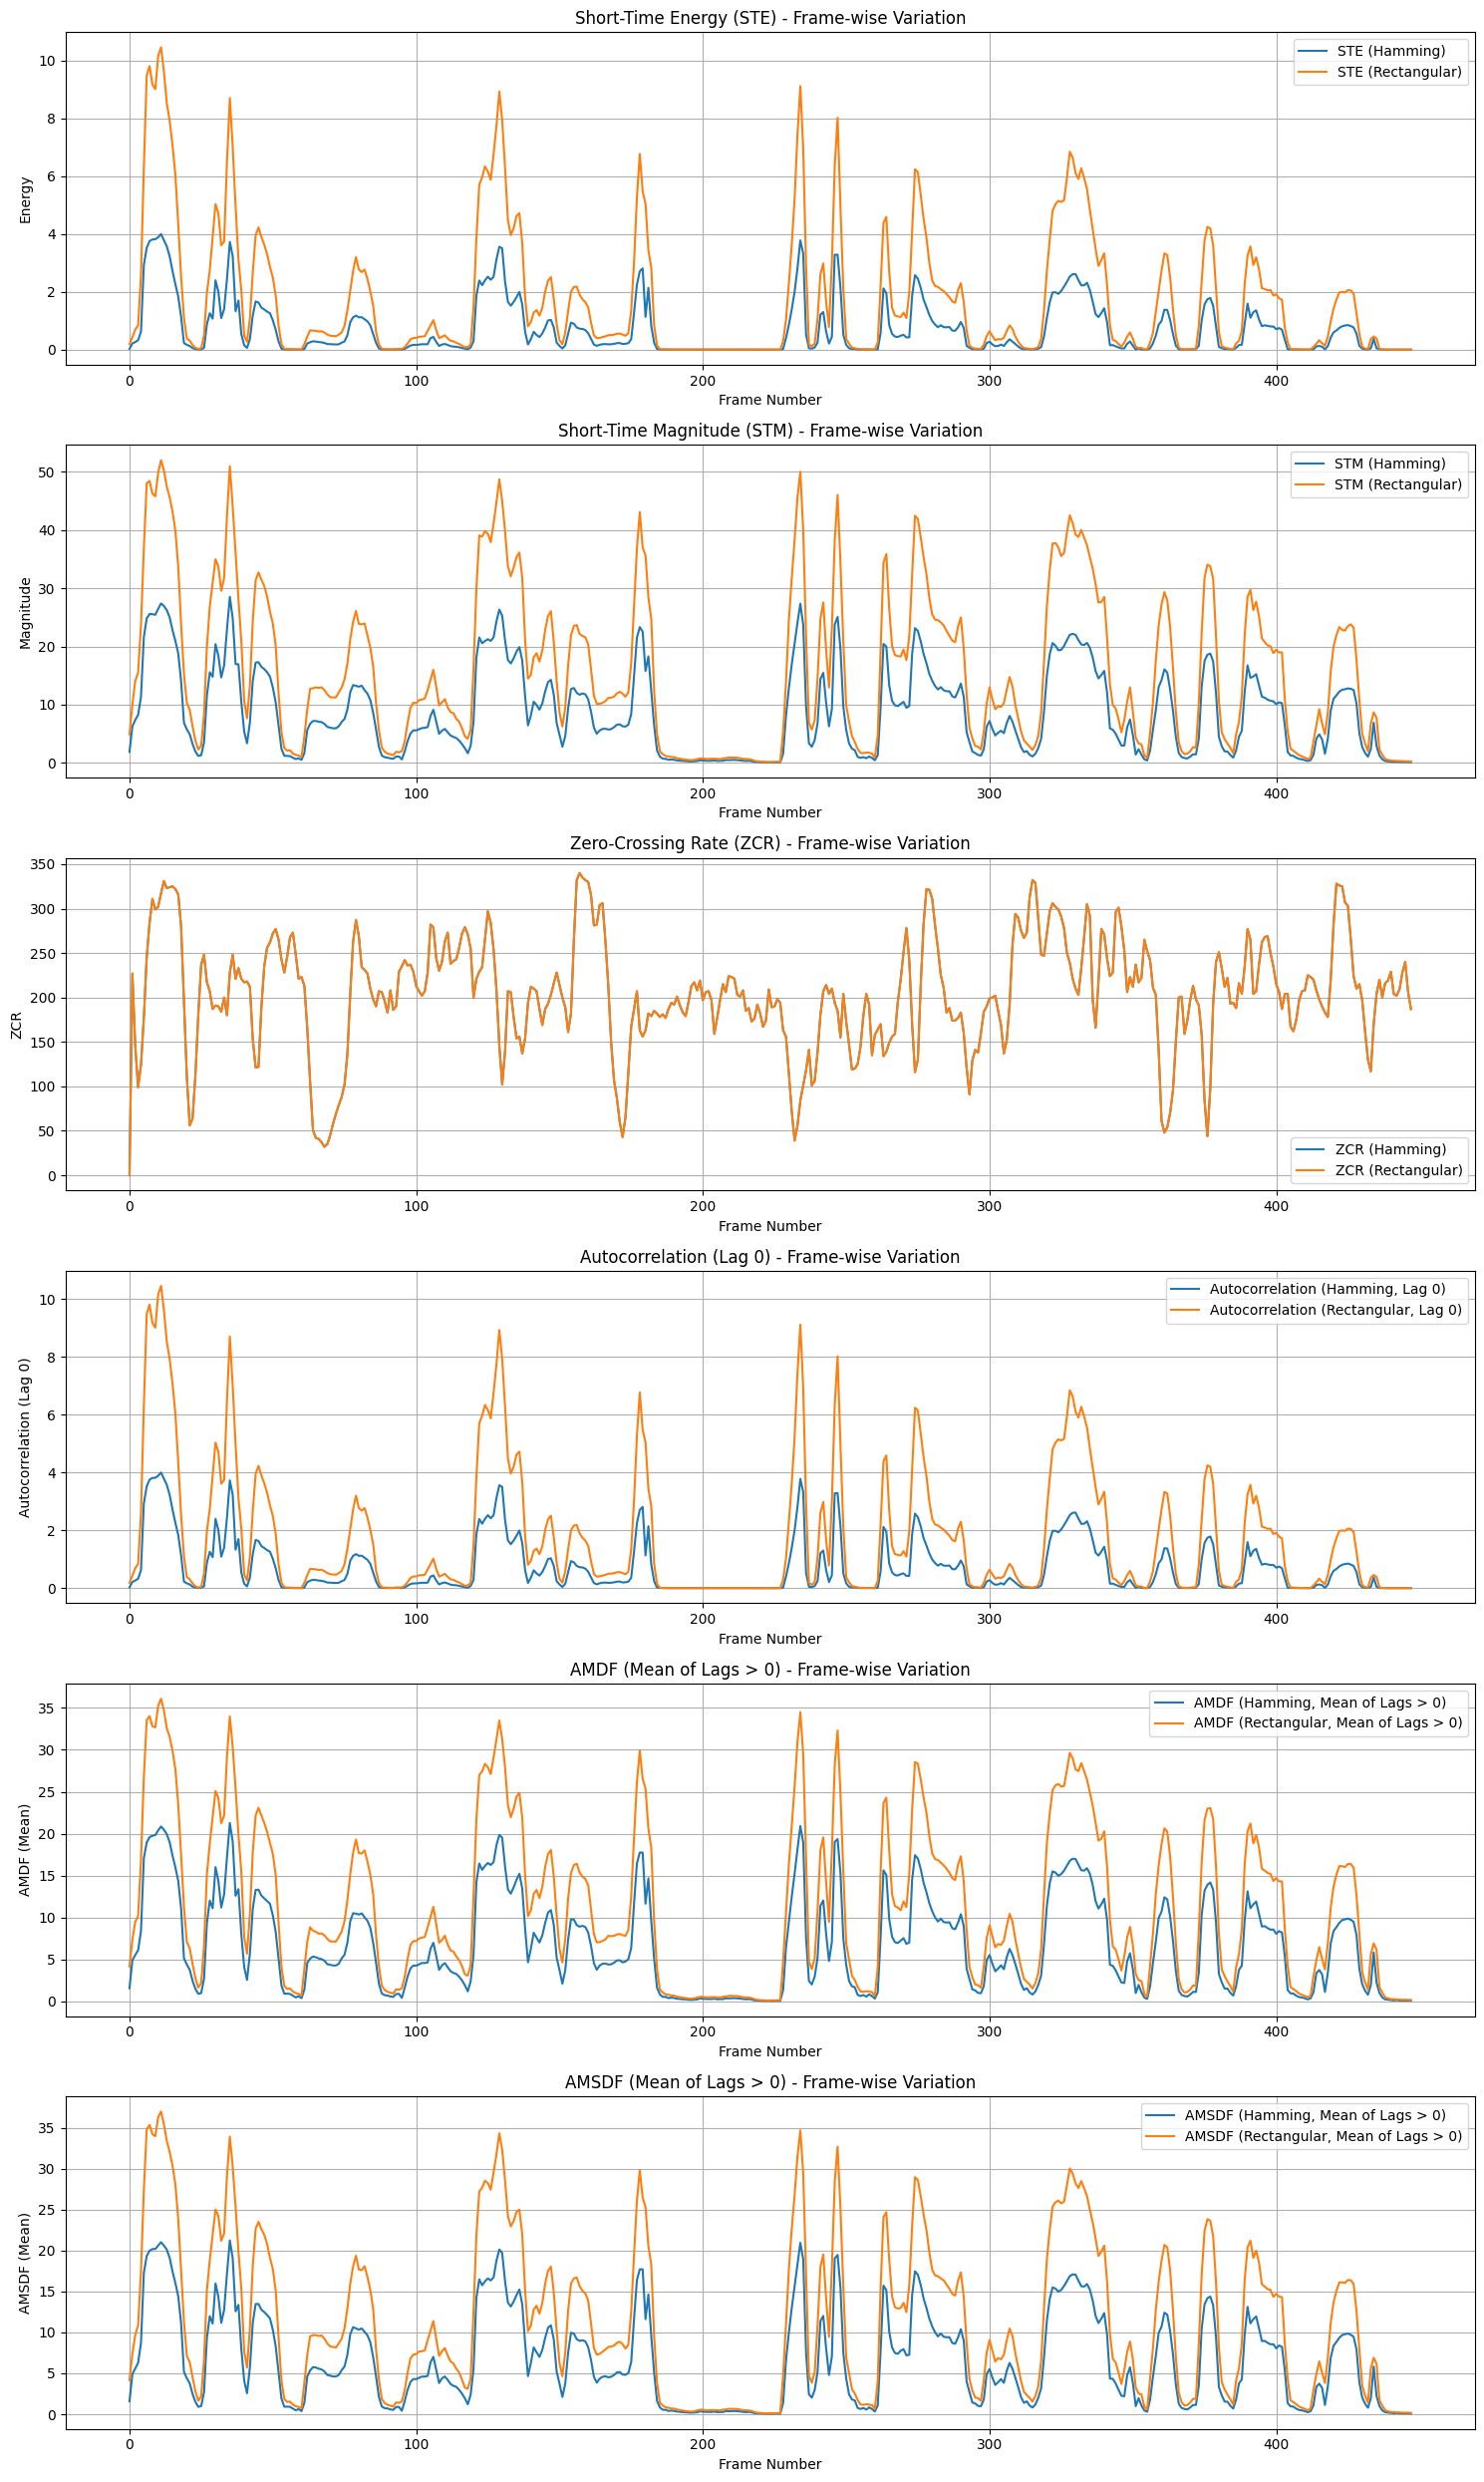

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the number of frames for x-axis
frame_indices = np.arange(num_frames)

plt.figure(figsize=(15, 25))

# Plot STE
plt.subplot(6, 1, 1)
plt.plot(frame_indices, STE, label='STE (Hamming)')
plt.plot(frame_indices, STE_rectangular, label='STE (Rectangular)')
plt.title('Short-Time Energy (STE) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)

# Plot STM
plt.subplot(6, 1, 2)
plt.plot(frame_indices, STM, label='STM (Hamming)')
plt.plot(frame_indices, STM_rectangular, label='STM (Rectangular)')
plt.title('Short-Time Magnitude (STM) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)

# Plot ZCR
plt.subplot(6, 1, 3)
plt.plot(frame_indices, ZCR, label='ZCR (Hamming)')
plt.plot(frame_indices, ZCR_rectangular, label='ZCR (Rectangular)')
plt.title('Zero-Crossing Rate (ZCR) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('ZCR')
plt.legend()
plt.grid(True)

# Plot Autocorrelation (e.g., value at lag 0, which is energy, or max value)
# For frame-wise comparison, let's plot the max autocorrelation value (excluding lag 0)
# Or simply the lag 0 value, which is essentially STE (though might be different due to different normalization/calculation of correlate vs sum of squares)
# Let's use the first value (lag 0) as a simple representation of frame-wise 'intensity' for autocorrelation.
plt.subplot(6, 1, 4)
plt.plot(frame_indices, autocorrelations[:, 0], label='Autocorrelation (Hamming, Lag 0)')
plt.plot(frame_indices, autocorrelations_rectangular[:, 0], label='Autocorrelation (Rectangular, Lag 0)')
plt.title('Autocorrelation (Lag 0) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('Autocorrelation (Lag 0)')
plt.legend()
plt.grid(True)

# Plot AMDF (e.g., minimum value excluding lag 0)
# Note: AMDF at lag 0 is just the sum of abs(frame), which is STM. So we plot the min value of other lags.
# To avoid division by zero or issues with frames where all values are zero, we can pick a safe lag, or check.
# For simpler frame-wise trend, let's use the average of the AMDF values (excluding lag 0).
plt.subplot(6, 1, 5)
plt.plot(frame_indices, np.mean(amdf[:, 1:], axis=1), label='AMDF (Hamming, Mean of Lags > 0)')
plt.plot(frame_indices, np.mean(amdf_rectangular[:, 1:], axis=1), label='AMDF (Rectangular, Mean of Lags > 0)')
plt.title('AMDF (Mean of Lags > 0) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('AMDF (Mean)')
plt.legend()
plt.grid(True)

# Plot AMSDF (e.g., minimum value excluding lag 0)
plt.subplot(6, 1, 6)
plt.plot(frame_indices, np.mean(amsdf[:, 1:], axis=1), label='AMSDF (Hamming, Mean of Lags > 0)')
plt.plot(frame_indices, np.mean(amsdf_rectangular[:, 1:], axis=1), label='AMSDF (Rectangular, Mean of Lags > 0)')
plt.title('AMSDF (Mean of Lags > 0) - Frame-wise Variation')
plt.xlabel('Frame Number')
plt.ylabel('AMSDF (Mean)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Define thresholds for STE and ZCR for Hamming window
# A common approach is to set the STE threshold as a percentage of its maximum value
ste_threshold_percentage = 0.1 # 10% of max STE
ste_threshold = np.max(STE) * ste_threshold_percentage

# For ZCR, voiced segments typically have lower ZCR compared to unvoiced segments
# The ZCR threshold is often determined empirically; let's use a value around 30% of max possible ZCR (frame_length_samples)
zcr_threshold_percentage = 0.3
zcr_threshold = frame_length_samples * zcr_threshold_percentage

# Define threshold for STE for Rectangular window
ste_rectangular_threshold_percentage = 0.1 # 10% of max STE_rectangular
ste_rectangular_threshold = np.max(STE_rectangular) * ste_rectangular_threshold_percentage

print(f"Hamming Window STE Threshold: {ste_threshold:.4f}")
print(f"ZCR Threshold: {zcr_threshold:.0f}")
print(f"Rectangular Window STE Threshold: {ste_rectangular_threshold:.4f}")

Hamming Window STE Threshold: 0.3997
ZCR Threshold: 120
Rectangular Window STE Threshold: 1.0459


In [ ]:
import numpy as np

# 1. Initialize lists for Hamming windowed data
voiced_frames_hamming = []
unvoiced_frames_hamming = []

# 2. Iterate through each frame for Hamming windowed data and apply classification logic
for i in range(num_frames):
    # If STE > ste_threshold AND ZCR < zcr_threshold, classify as voiced
    if STE[i] > ste_threshold and ZCR[i] < zcr_threshold:
        voiced_frames_hamming.append(i)
    else:
        unvoiced_frames_hamming.append(i)

# 3. Convert lists to NumPy arrays
voiced_segments_hamming_indices = np.array(voiced_frames_hamming)
unvoiced_segments_hamming_indices = np.array(unvoiced_frames_hamming)

# 4. Initialize lists for Rectangular windowed data
voiced_frames_rectangular = []
unvoiced_frames_rectangular = []

# 5. Iterate through each frame for Rectangular windowed data and apply classification logic
for i in range(num_frames):
    # If STE_rectangular > ste_rectangular_threshold AND ZCR_rectangular < zcr_threshold, classify as voiced
    if STE_rectangular[i] > ste_rectangular_threshold and ZCR_rectangular[i] < zcr_threshold:
        voiced_frames_rectangular.append(i)
    else:
        unvoiced_frames_rectangular.append(i)

# 6. Convert lists to NumPy arrays
voiced_segments_rectangular_indices = np.array(voiced_frames_rectangular)
unvoiced_segments_rectangular_indices = np.array(unvoiced_frames_rectangular)

# 7. Print the total number of voiced and unvoiced frames for both window functions
print(f"--- Hamming Windowed Data ---")
print(f"Total voiced frames (Hamming): {len(voiced_segments_hamming_indices)}")
print(f"Total unvoiced frames (Hamming): {len(unvoiced_segments_hamming_indices)}")

print(f"\n--- Rectangular Windowed Data ---")
print(f"Total voiced frames (Rectangular): {len(voiced_segments_rectangular_indices)}")
print(f"Total unvoiced frames (Rectangular): {len(unvoiced_segments_rectangular_indices)}")

--- Hamming Windowed Data ---
Total voiced frames (Hamming): 17
Total unvoiced frames (Hamming): 431

--- Rectangular Windowed Data ---
Total voiced frames (Rectangular): 17
Total unvoiced frames (Rectangular): 431


# Task-1g: Analyse and compare the behaviour of all 6 extracted time-domain features for voiced and unvoiced speech segments. Infer your observation for each feature and summarize the findings.

In [ ]:
import numpy as np

# 1. Extract Autocorrelation (Lag 0) for Hamming windowed frames
autocorrelation_lag0 = autocorrelations[:, 0]

# 2. Extract Autocorrelation (Lag 0) for Rectangular windowed frames
autocorrelation_rectangular_lag0 = autocorrelations_rectangular[:, 0]

# 3. Calculate the mean of AMDF values for lags greater than 0 for Hamming windowed frames
amdf_mean_lags_gt0 = np.mean(amdf[:, 1:], axis=1)

# 4. Calculate the mean of AMDF values for lags greater than 0 for Rectangular windowed frames
amdf_rectangular_mean_lags_gt0 = np.mean(amdf_rectangular[:, 1:], axis=1)

# 5. Calculate the mean of AMSDF values for lags greater than 0 for Hamming windowed frames
amsdf_mean_lags_gt0 = np.mean(amsdf[:, 1:], axis=1)

# 6. Calculate the mean of AMSDF values for lags greater than 0 for Rectangular windowed frames
amsdf_rectangular_mean_lags_gt0 = np.mean(amsdf_rectangular[:, 1:], axis=1)

print(f"Shape of Autocorrelation (Lag 0) Hamming: {autocorrelation_lag0.shape}")
print(f"Shape of Autocorrelation (Lag 0) Rectangular: {autocorrelation_rectangular_lag0.shape}")
print(f"Shape of AMDF Mean (Lags > 0) Hamming: {amdf_mean_lags_gt0.shape}")
print(f"Shape of AMDF Mean (Lags > 0) Rectangular: {amdf_rectangular_mean_lags_gt0.shape}")
print(f"Shape of AMSDF Mean (Lags > 0) Hamming: {amsdf_mean_lags_gt0.shape}")
print(f"Shape of AMSDF Mean (Lags > 0) Rectangular: {amsdf_rectangular_mean_lags_gt0.shape}")

Shape of Autocorrelation (Lag 0) Hamming: (448,)
Shape of Autocorrelation (Lag 0) Rectangular: (448,)
Shape of AMDF Mean (Lags > 0) Hamming: (448,)
Shape of AMDF Mean (Lags > 0) Rectangular: (448,)
Shape of AMSDF Mean (Lags > 0) Hamming: (448,)
Shape of AMSDF Mean (Lags > 0) Rectangular: (448,)


In [ ]:
import pandas as pd

# Initialize a list to store all calculated statistics
all_stats = []

# Define the features and their corresponding arrays for Hamming and Rectangular windows
features_data = {
    'STE': {'Hamming': STE, 'Rectangular': STE_rectangular},
    'STM': {'Hamming': STM, 'Rectangular': STM_rectangular},
    'ZCR': {'Hamming': ZCR, 'Rectangular': ZCR_rectangular},
    'Autocorrelation (Lag 0)': {'Hamming': autocorrelation_lag0, 'Rectangular': autocorrelation_rectangular_lag0},
    'AMDF (Mean Lags > 0)': {'Hamming': amdf_mean_lags_gt0, 'Rectangular': amdf_rectangular_mean_lags_gt0},
    'AMSDF (Mean Lags > 0)': {'Hamming': amsdf_mean_lags_gt0, 'Rectangular': amsdf_rectangular_mean_lags_gt0}
}

# Iterate through each feature
for feature_name, window_data in features_data.items():
    # Iterate through Hamming and Rectangular windows
    for window_type, feature_array in window_data.items():

        if window_type == 'Hamming':
            voiced_indices = voiced_segments_hamming_indices
            unvoiced_indices = unvoiced_segments_hamming_indices
        else: # Rectangular
            voiced_indices = voiced_segments_rectangular_indices
            unvoiced_indices = unvoiced_segments_rectangular_indices

        # Extract values for voiced and unvoiced segments
        voiced_values = feature_array[voiced_indices]
        unvoiced_values = feature_array[unvoiced_indices]

        # Calculate statistics
        voiced_mean = np.mean(voiced_values) if len(voiced_values) > 0 else np.nan
        voiced_std = np.std(voiced_values) if len(voiced_values) > 0 else np.nan
        unvoiced_mean = np.mean(unvoiced_values) if len(unvoiced_values) > 0 else np.nan
        unvoiced_std = np.std(unvoiced_values) if len(unvoiced_values) > 0 else np.nan

        # Store results
        all_stats.append({
            'Feature': feature_name,
            'Window': window_type,
            'Voiced_Mean': voiced_mean,
            'Voiced_Std': voiced_std,
            'Unvoiced_Mean': unvoiced_mean,
            'Unvoiced_Std': unvoiced_std
        })

# Convert the list of dictionaries to a Pandas DataFrame
stats_df = pd.DataFrame(all_stats)

print("Statistical measures DataFrame created successfully:")
print(stats_df)

Statistical measures DataFrame created successfully:
                    Feature       Window  Voiced_Mean  Voiced_Std  \
0                       STE      Hamming     1.833036    0.992426   
1                       STE  Rectangular     4.538707    2.168513   
2                       STM      Hamming    17.985155    5.302951   
3                       STM  Rectangular    33.116749    9.109287   
4                       ZCR      Hamming    79.882353   25.758796   
5                       ZCR  Rectangular    79.882353   25.758796   
6   Autocorrelation (Lag 0)      Hamming     1.833036    0.992426   
7   Autocorrelation (Lag 0)  Rectangular     4.538707    2.168513   
8      AMDF (Mean Lags > 0)      Hamming    13.734791    4.026914   
9      AMDF (Mean Lags > 0)  Rectangular    23.037374    5.966308   
10    AMSDF (Mean Lags > 0)      Hamming    13.886301    4.020285   
11    AMSDF (Mean Lags > 0)  Rectangular    23.590460    6.000552   

    Unvoiced_Mean  Unvoiced_Std  
0        0.6541

In [ ]:
print(stats_df[stats_df['Feature'] == 'STE'].to_string())

  Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
0     STE      Hamming     1.833036    0.992426       0.654191      0.898565
1     STE  Rectangular     4.538707    2.168513       1.659761      2.208495


In [ ]:
print(stats_df[stats_df['Feature'] == 'STM'].to_string())

  Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
2     STM      Hamming    17.985155    5.302951       8.302755      7.267217
3     STM  Rectangular    33.116749    9.109287      15.455075     13.277125


In [ ]:
print(stats_df[stats_df['Feature'] == 'ZCR'].to_string())

  Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
4     ZCR      Hamming    79.882353   25.758796      208.24826      60.14716
5     ZCR  Rectangular    79.882353   25.758796      208.24826      60.14716


In [ ]:
print(stats_df[stats_df['Feature'] == 'Autocorrelation (Lag 0)'].to_string())

                   Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
6  Autocorrelation (Lag 0)      Hamming     1.833036    0.992426       0.654191      0.898565
7  Autocorrelation (Lag 0)  Rectangular     4.538707    2.168513       1.659761      2.208495


In [ ]:
print(stats_df[stats_df['Feature'] == 'AMDF (Mean Lags > 0)'].to_string())

                Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
8  AMDF (Mean Lags > 0)      Hamming    13.734791    4.026914       6.382803      5.582691
9  AMDF (Mean Lags > 0)  Rectangular    23.037374    5.966308      10.941745      9.293290


In [ ]:
print(stats_df[stats_df['Feature'] == 'AMSDF (Mean Lags > 0)'].to_string())

                  Feature       Window  Voiced_Mean  Voiced_Std  Unvoiced_Mean  Unvoiced_Std
10  AMSDF (Mean Lags > 0)      Hamming    13.886301    4.020285       6.424947      5.606664
11  AMSDF (Mean Lags > 0)  Rectangular    23.590460    6.000552      11.108792      9.405218


The analysis compared six time-domain speech features (STE, STM, ZCR, Autocorrelation, AMDF, AMSDF) for voiced and unvoiced segments using Hamming and Rectangular windows.

Voiced speech shows higher energy- and magnitude-based feature values (STE, STM, Autocorrelation, AMDF, AMSDF), while unvoiced speech has a higher Zero-Crossing Rate (ZCR). Voiced segments also generally have greater variability in these features.

The Rectangular window produces higher absolute energy and magnitude values than the Hamming window because it does not taper the signal. However, both windows maintain the same relative distinction between voiced and unvoiced speech. ZCR is unaffected by the choice of window.

Overall, both window types effectively distinguish voiced from unvoiced speech, with differences mainly in the absolute scaling of amplitude-based features.

# Task-1h: Comment on the effect of window choice on feature smoothness and discrimination capability.

**The Hamming window smooths features, reducing abrupt changes and magnitude-based values, leading to more stable discrimination. The Rectangular window retains full signal magnitude, resulting in higher feature values but potentially more variability. ZCR's discrimination capability remains unaffected by window choice.**



# Task-2

In [ ]:
import numpy as np

# 1. Define the minimum and maximum expected fundamental frequencies (F0) for human speech
min_f0_hz = 50  # Hz (typical lower bound for male speech)
max_f0_hz = 400 # Hz (typical upper bound for female speech/children)

# 2. Convert these F0 frequencies into corresponding pitch periods (T0) in seconds
# T0 = 1 / F0
min_t0_s = 1 / max_f0_hz # Shorter period for higher frequency
max_t0_s = 1 / min_f0_hz # Longer period for lower frequency

# 3. Convert the pitch periods from seconds to samples by multiplying by the sampling rate (sr)
# The 'sr' variable was defined in a previous cell (zetrDmCHsXWU)
min_lag_samples = int(min_t0_s * sr)
max_lag_samples = int(max_t0_s * sr)

# Ensure min_lag_samples is at least 1 for valid lag calculations
min_lag_samples = max(1, min_lag_samples)

# Also ensure max_lag_samples does not exceed frame_length_samples for autocorrelation/AMDF/AMSDF calculations
# (though we might search slightly beyond, for now, we'll keep it within frame length for these feature interpretations)
max_lag_samples = min(max_lag_samples, frame_length_samples - 1)


# 4. Define an empirical threshold for Autocorrelation
# For periodicity, the peak in autocorrelation at the pitch lag should be sufficiently high.
# A value between 0.3 to 0.7 is common. We'll start with 0.35.
autocorr_threshold = 0.35

# 5. Define an empirical threshold for AMDF
# AMDF exhibits a minimum (valley) at the pitch lag. A low value (relative to its maximum) indicates periodicity.
# A threshold of 0.4 means the AMDF value at the pitch lag should be less than 40% of the overall maximum AMDF in the search range.
amdf_threshold = 0.4

# 6. Define an empirical threshold for AMSDF
# AMSDF also exhibits a minimum (valley) at the pitch lag. Similar to AMDF, a low value indicates periodicity.
# A threshold of 0.4 means the AMSDF value at the pitch lag should be less than 40% of the overall maximum AMSDF in the search range.
amsdf_threshold = 0.4

# 7. Print the calculated values
print(f"--- Pitch Lag Search Range ---")
print(f"Minimum F0 (Hz): {min_f0_hz}")
print(f"Maximum F0 (Hz): {max_f0_hz}")
print(f"Minimum Pitch Period (samples): {min_lag_samples}")
print(f"Maximum Pitch Period (samples): {max_lag_samples}")

print(f"\n--- Periodicity Thresholds ---")
print(f"Autocorrelation Threshold: {autocorr_threshold}")
print(f"AMDF Threshold: {amdf_threshold}")
print(f"AMSDF Threshold: {amsdf_threshold}")

--- Pitch Lag Search Range ---
Minimum F0 (Hz): 50
Maximum F0 (Hz): 400
Minimum Pitch Period (samples): 40
Maximum Pitch Period (samples): 320

--- Periodicity Thresholds ---
Autocorrelation Threshold: 0.35
AMDF Threshold: 0.4
AMSDF Threshold: 0.4


In [ ]:
import numpy as np

# 1. Initialize lists for periodic frame indices
periodic_autocorr_hamming_indices = []
periodic_autocorr_rectangular_indices = []

# Iterate through each frame
for i in range(num_frames):
    # Extract autocorrelation values within the pitch lag search range
    # +1 to max_lag_samples to include the max_lag_samples index itself
    autocorr_segment_hamming = autocorrelations[i, min_lag_samples : max_lag_samples + 1]
    autocorr_segment_rectangular = autocorrelations_rectangular[i, min_lag_samples : max_lag_samples + 1]

    # 4. Find the maximum autocorrelation value within this defined pitch lag range
    # Ensure the segment is not empty before finding max
    if len(autocorr_segment_hamming) > 0:
        max_autocorr_hamming = np.max(autocorr_segment_hamming)
    else:
        max_autocorr_hamming = -np.inf # Assign a very small value if no valid lags

    if len(autocorr_segment_rectangular) > 0:
        max_autocorr_rectangular = np.max(autocorr_segment_rectangular)
    else:
        max_autocorr_rectangular = -np.inf # Assign a very small value if no valid lags

    # 5. Compare this maximum value against the autocorr_threshold
    # 6. If the maximum autocorrelation value is greater than the autocorr_threshold,
    #    add the current frame's index to the corresponding periodic frames list.
    if max_autocorr_hamming > autocorr_threshold:
        periodic_autocorr_hamming_indices.append(i)

    if max_autocorr_rectangular > autocorr_threshold:
        periodic_autocorr_rectangular_indices.append(i)

# 7. After iterating through all frames, convert the lists of periodic frame indices into NumPy arrays.
periodic_autocorr_hamming_indices = np.array(periodic_autocorr_hamming_indices)
periodic_autocorr_rectangular_indices = np.array(periodic_autocorr_rectangular_indices)

# 8. Print the total number of periodic frames found for both Hamming and Rectangular windowed data
print(f"Number of periodic frames (Autocorrelation, Hamming window): {len(periodic_autocorr_hamming_indices)}")
print(f"Number of periodic frames (Autocorrelation, Rectangular window): {len(periodic_autocorr_rectangular_indices)}")

Number of periodic frames (Autocorrelation, Hamming window): 167
Number of periodic frames (Autocorrelation, Rectangular window): 225


In [ ]:
import numpy as np

# 1. Initialize lists for periodic frame indices using AMDF
periodic_amdf_hamming_indices = []
periodic_amdf_rectangular_indices = []

# Iterate through each frame
for i in range(num_frames):
    # Extract AMDF values within the pitch lag search range
    # Note: AMDF is typically minimal at pitch lag, so we look for minimums.
    # +1 to max_lag_samples to include the max_lag_samples index itself
    amdf_segment_hamming = amdf[i, min_lag_samples : max_lag_samples + 1]
    amdf_segment_rectangular = amdf_rectangular[i, min_lag_samples : max_lag_samples + 1]

    # Also, get the maximum AMDF value in the segment to normalize the minimum
    max_amdf_segment_hamming = np.max(amdf[i, 1:]) # Max over all lags (excluding lag 0, which is STM)
    max_amdf_segment_rectangular = np.max(amdf_rectangular[i, 1:])

    # 4. Find the minimum AMDF value within this defined pitch lag range
    # Ensure the segment is not empty before finding min
    if len(amdf_segment_hamming) > 0 and max_amdf_segment_hamming > 0:
        min_amdf_hamming = np.min(amdf_segment_hamming)
        # Normalizing the minimum AMDF value
        normalized_min_amdf_hamming = min_amdf_hamming / max_amdf_segment_hamming
    else:
        normalized_min_amdf_hamming = np.inf # Assign a very large value if no valid lags or max is zero

    if len(amdf_segment_rectangular) > 0 and max_amdf_segment_rectangular > 0:
        min_amdf_rectangular = np.min(amdf_segment_rectangular)
        # Normalizing the minimum AMDF value
        normalized_min_amdf_rectangular = min_amdf_rectangular / max_amdf_segment_rectangular
    else:
        normalized_min_amdf_rectangular = np.inf # Assign a very large value if no valid lags or max is zero

    # 5. Compare this normalized minimum value against the amdf_threshold
    # 6. If the normalized minimum AMDF value is less than the amdf_threshold,
    #    add the current frame's index to the corresponding periodic frames list.
    if normalized_min_amdf_hamming < amdf_threshold:
        periodic_amdf_hamming_indices.append(i)

    if normalized_min_amdf_rectangular < amdf_threshold:
        periodic_amdf_rectangular_indices.append(i)

# 7. After iterating through all frames, convert the lists of periodic frame indices into NumPy arrays.
periodic_amdf_hamming_indices = np.array(periodic_amdf_hamming_indices)
periodic_amdf_rectangular_indices = np.array(periodic_amdf_rectangular_indices)

# 8. Print the total number of periodic frames found for both Hamming and Rectangular windowed data
print(f"Number of periodic frames (AMDF, Hamming window): {len(periodic_amdf_hamming_indices)}")
print(f"Number of periodic frames (AMDF, Rectangular window): {len(periodic_amdf_rectangular_indices)}")

Number of periodic frames (AMDF, Hamming window): 448
Number of periodic frames (AMDF, Rectangular window): 447


In [ ]:
import numpy as np

# 1. Initialize lists for periodic frame indices using AMSDF
periodic_amsdf_hamming_indices = []
periodic_amsdf_rectangular_indices = []

# Iterate through each frame
for i in range(num_frames):
    # Extract AMSDF values within the pitch lag search range
    # Note: AMSDF is typically minimal at pitch lag, so we look for minimums.
    # +1 to max_lag_samples to include the max_lag_samples index itself
    amsdf_segment_hamming = amsdf[i, min_lag_samples : max_lag_samples + 1]
    amsdf_segment_rectangular = amsdf_rectangular[i, min_lag_samples : max_lag_samples + 1]

    # Also, get the maximum AMSDF value in the segment to normalize the minimum
    max_amsdf_segment_hamming = np.max(amsdf[i, 1:]) # Max over all lags (excluding lag 0, which is STM)
    max_amsdf_segment_rectangular = np.max(amsdf_rectangular[i, 1:])

    # 4. Find the minimum AMSDF value within this defined pitch lag range
    # Ensure the segment is not empty before finding min
    if len(amsdf_segment_hamming) > 0 and max_amsdf_segment_hamming > 0:
        min_amsdf_hamming = np.min(amsdf_segment_hamming)
        # Normalizing the minimum AMSDF value
        normalized_min_amsdf_hamming = min_amsdf_hamming / max_amsdf_segment_hamming
    else:
        normalized_min_amsdf_hamming = np.inf # Assign a very large value if no valid lags or max is zero

    if len(amsdf_segment_rectangular) > 0 and max_amsdf_segment_rectangular > 0:
        min_amsdf_rectangular = np.min(amsdf_segment_rectangular)
        # Normalizing the minimum AMSDF value
        normalized_min_amsdf_rectangular = min_amsdf_rectangular / max_amsdf_segment_rectangular
    else:
        normalized_min_amsdf_rectangular = np.inf # Assign a very large value if no valid lags or max is zero

    # 5. Compare this normalized minimum value against the amsdf_threshold
    # 6. If the normalized minimum AMSDF value is less than the amsdf_threshold,
    #    add the current frame's index to the corresponding periodic frames list.
    if normalized_min_amsdf_hamming < amsdf_threshold:
        periodic_amsdf_hamming_indices.append(i)

    if normalized_min_amsdf_rectangular < amsdf_threshold:
        periodic_amsdf_rectangular_indices.append(i)

# 7. After iterating through all frames, convert the lists of periodic frame indices into NumPy arrays.
periodic_amsdf_hamming_indices = np.array(periodic_amsdf_hamming_indices)
periodic_amsdf_rectangular_indices = np.array(periodic_amsdf_rectangular_indices)

# 8. Print the total number of periodic frames found for both Hamming and Rectangular windowed data
print(f"Number of periodic frames (AMSDF, Hamming window): {len(periodic_amsdf_hamming_indices)}")
print(f"Number of periodic frames (AMSDF, Rectangular window): {len(periodic_amsdf_rectangular_indices)}")

Number of periodic frames (AMSDF, Hamming window): 448
Number of periodic frames (AMSDF, Rectangular window): 448


Selected representative voiced frame index (Rectangular): 130
Selected representative unvoiced frame index (Rectangular): 0


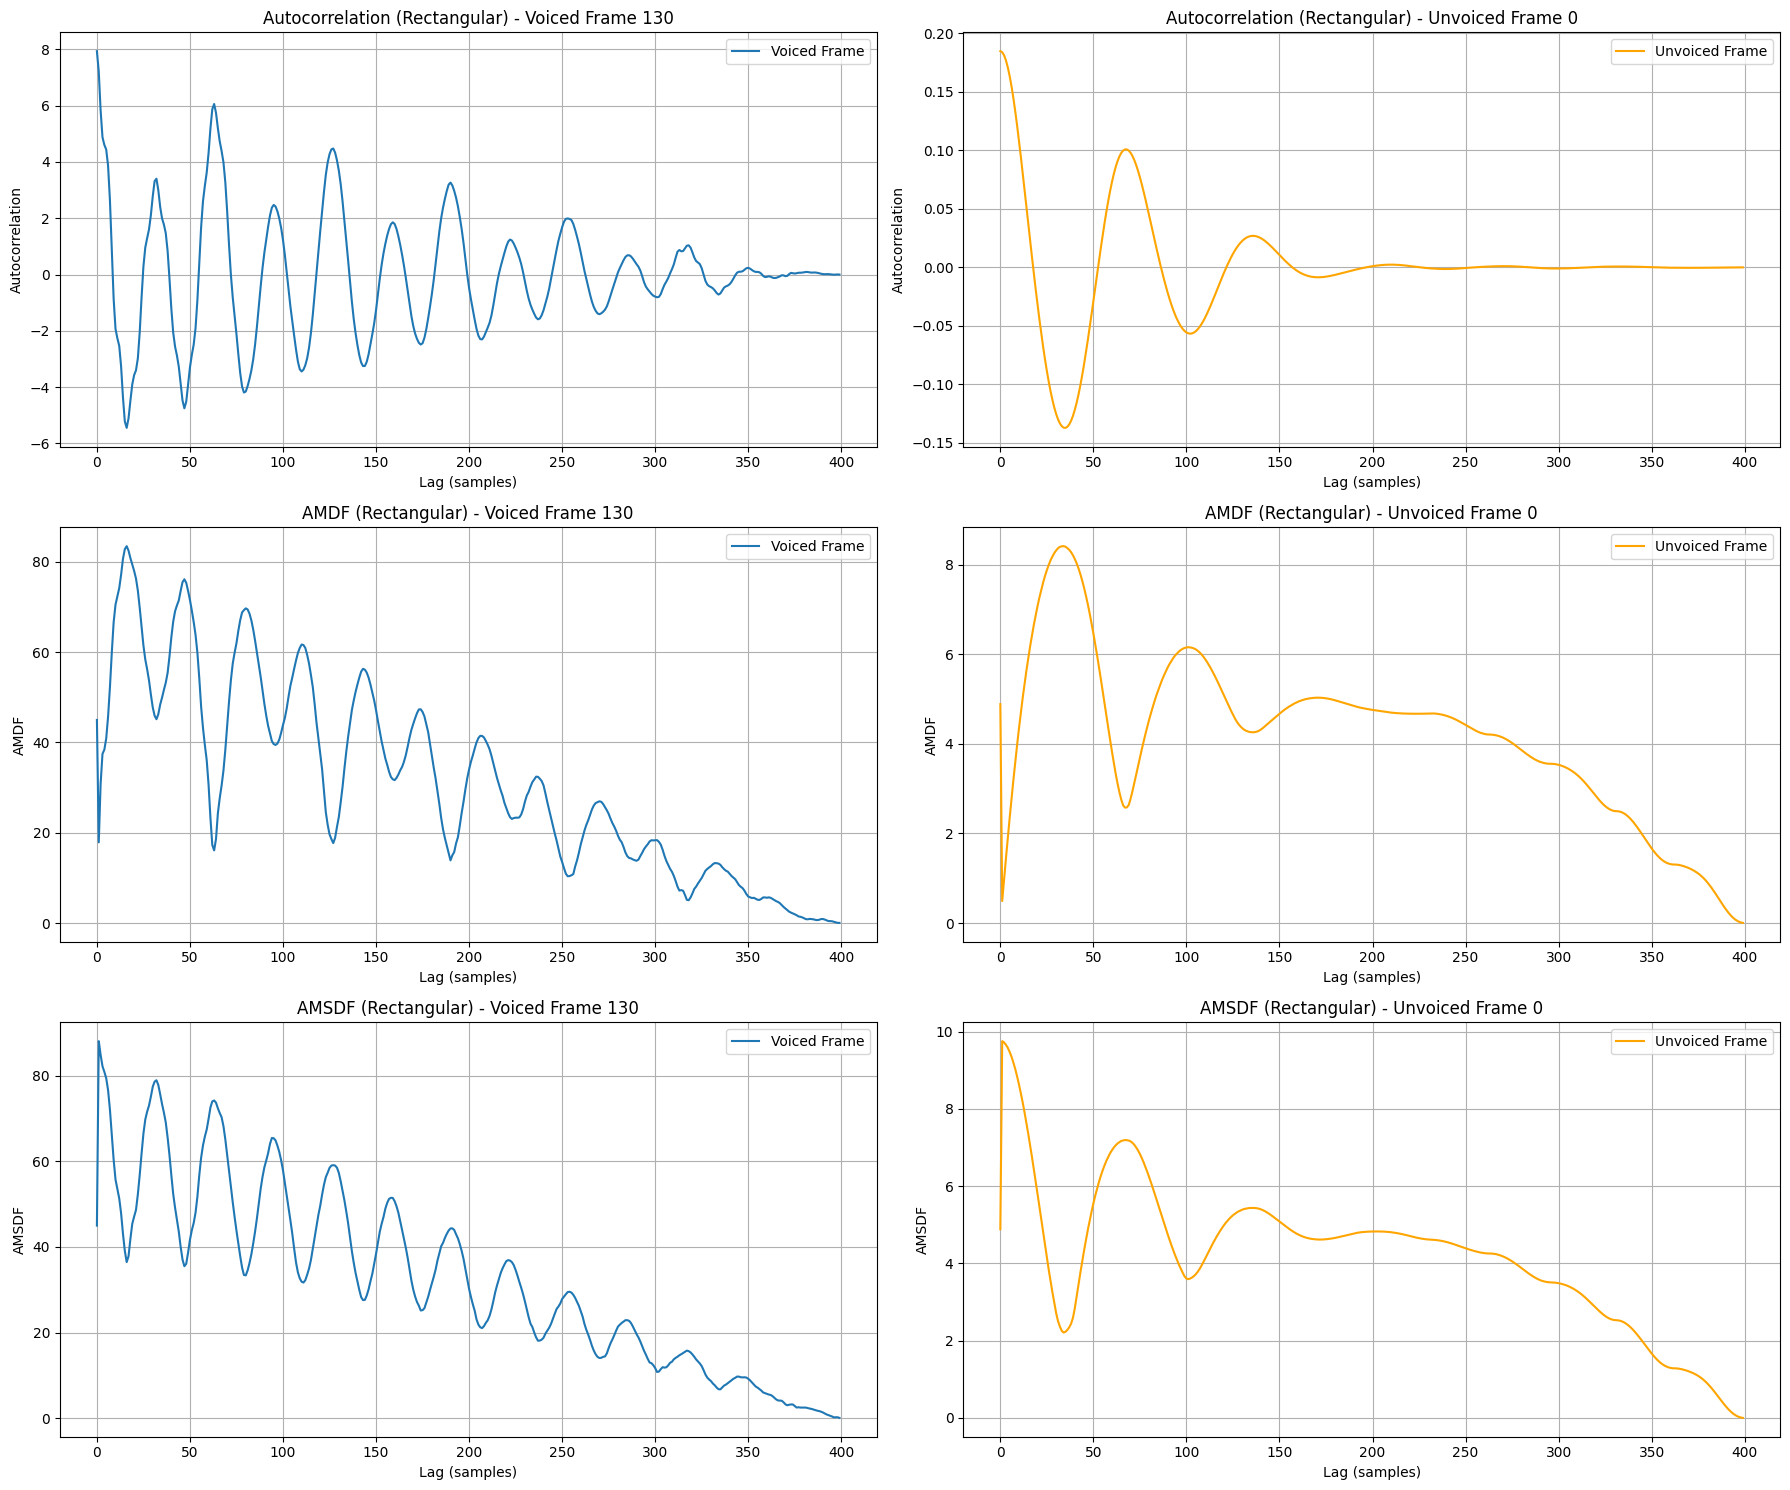

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select representative voiced and unvoiced frames (Rectangular windowed)
if len(voiced_segments_rectangular_indices) > 0:
    voiced_frame_idx_rect = voiced_segments_rectangular_indices[0]
    print(f"Selected representative voiced frame index (Rectangular): {voiced_frame_idx_rect}")
else:
    print("Warning: No voiced frames identified with Rectangular window. Selecting a default frame for demonstration.")
    voiced_frame_idx_rect = num_frames // 4 # Fallback if no voiced frames

if len(unvoiced_segments_rectangular_indices) > 0:
    unvoiced_frame_idx_rect = unvoiced_segments_rectangular_indices[0]
    print(f"Selected representative unvoiced frame index (Rectangular): {unvoiced_frame_idx_rect}")
else:
    print("Warning: No unvoiced frames identified with Rectangular window. Selecting a default frame for demonstration.")
    unvoiced_frame_idx_rect = num_frames // 2 # Fallback if no unvoiced frames

# Get the feature curves for the selected frames (Rectangular windowed)
autocorr_voiced_rect = autocorrelations_rectangular[voiced_frame_idx_rect, :]
amdf_voiced_rect = amdf_rectangular[voiced_frame_idx_rect, :]
amsdf_voiced_rect = amsdf_rectangular[voiced_frame_idx_rect, :]

autocorr_unvoiced_rect = autocorrelations_rectangular[unvoiced_frame_idx_rect, :]
amdf_unvoiced_rect = amdf_rectangular[unvoiced_frame_idx_rect, :]
amsdf_unvoiced_rect = amsdf_rectangular[unvoiced_frame_idx_rect, :]

# Create a lag axis (in samples)
lag_axis = np.arange(frame_length_samples)

plt.figure(figsize=(18, 15))

# --- Plot Autocorrelation ---
plt.subplot(3, 2, 1)
plt.plot(lag_axis, autocorr_voiced_rect, label='Voiced Frame')
plt.title(f'Autocorrelation (Rectangular) - Voiced Frame {voiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(lag_axis, autocorr_unvoiced_rect, label='Unvoiced Frame', color='orange')
plt.title(f'Autocorrelation (Rectangular) - Unvoiced Frame {unvoiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()

# --- Plot AMDF ---
plt.subplot(3, 2, 3)
plt.plot(lag_axis, amdf_voiced_rect, label='Voiced Frame')
plt.title(f'AMDF (Rectangular) - Voiced Frame {voiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMDF')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(lag_axis, amdf_unvoiced_rect, label='Unvoiced Frame', color='orange')
plt.title(f'AMDF (Rectangular) - Unvoiced Frame {unvoiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMDF')
plt.grid(True)
plt.legend()

# --- Plot AMSDF ---
plt.subplot(3, 2, 5)
plt.plot(lag_axis, amsdf_voiced_rect, label='Voiced Frame')
plt.title(f'AMSDF (Rectangular) - Voiced Frame {voiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMSDF')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 6)
plt.plot(lag_axis, amsdf_unvoiced_rect, label='Unvoiced Frame', color='orange')
plt.title(f'AMSDF (Rectangular) - Unvoiced Frame {unvoiced_frame_idx_rect}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMSDF')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Selected representative voiced frame index (Hamming): 130
Selected representative unvoiced frame index (Hamming): 0


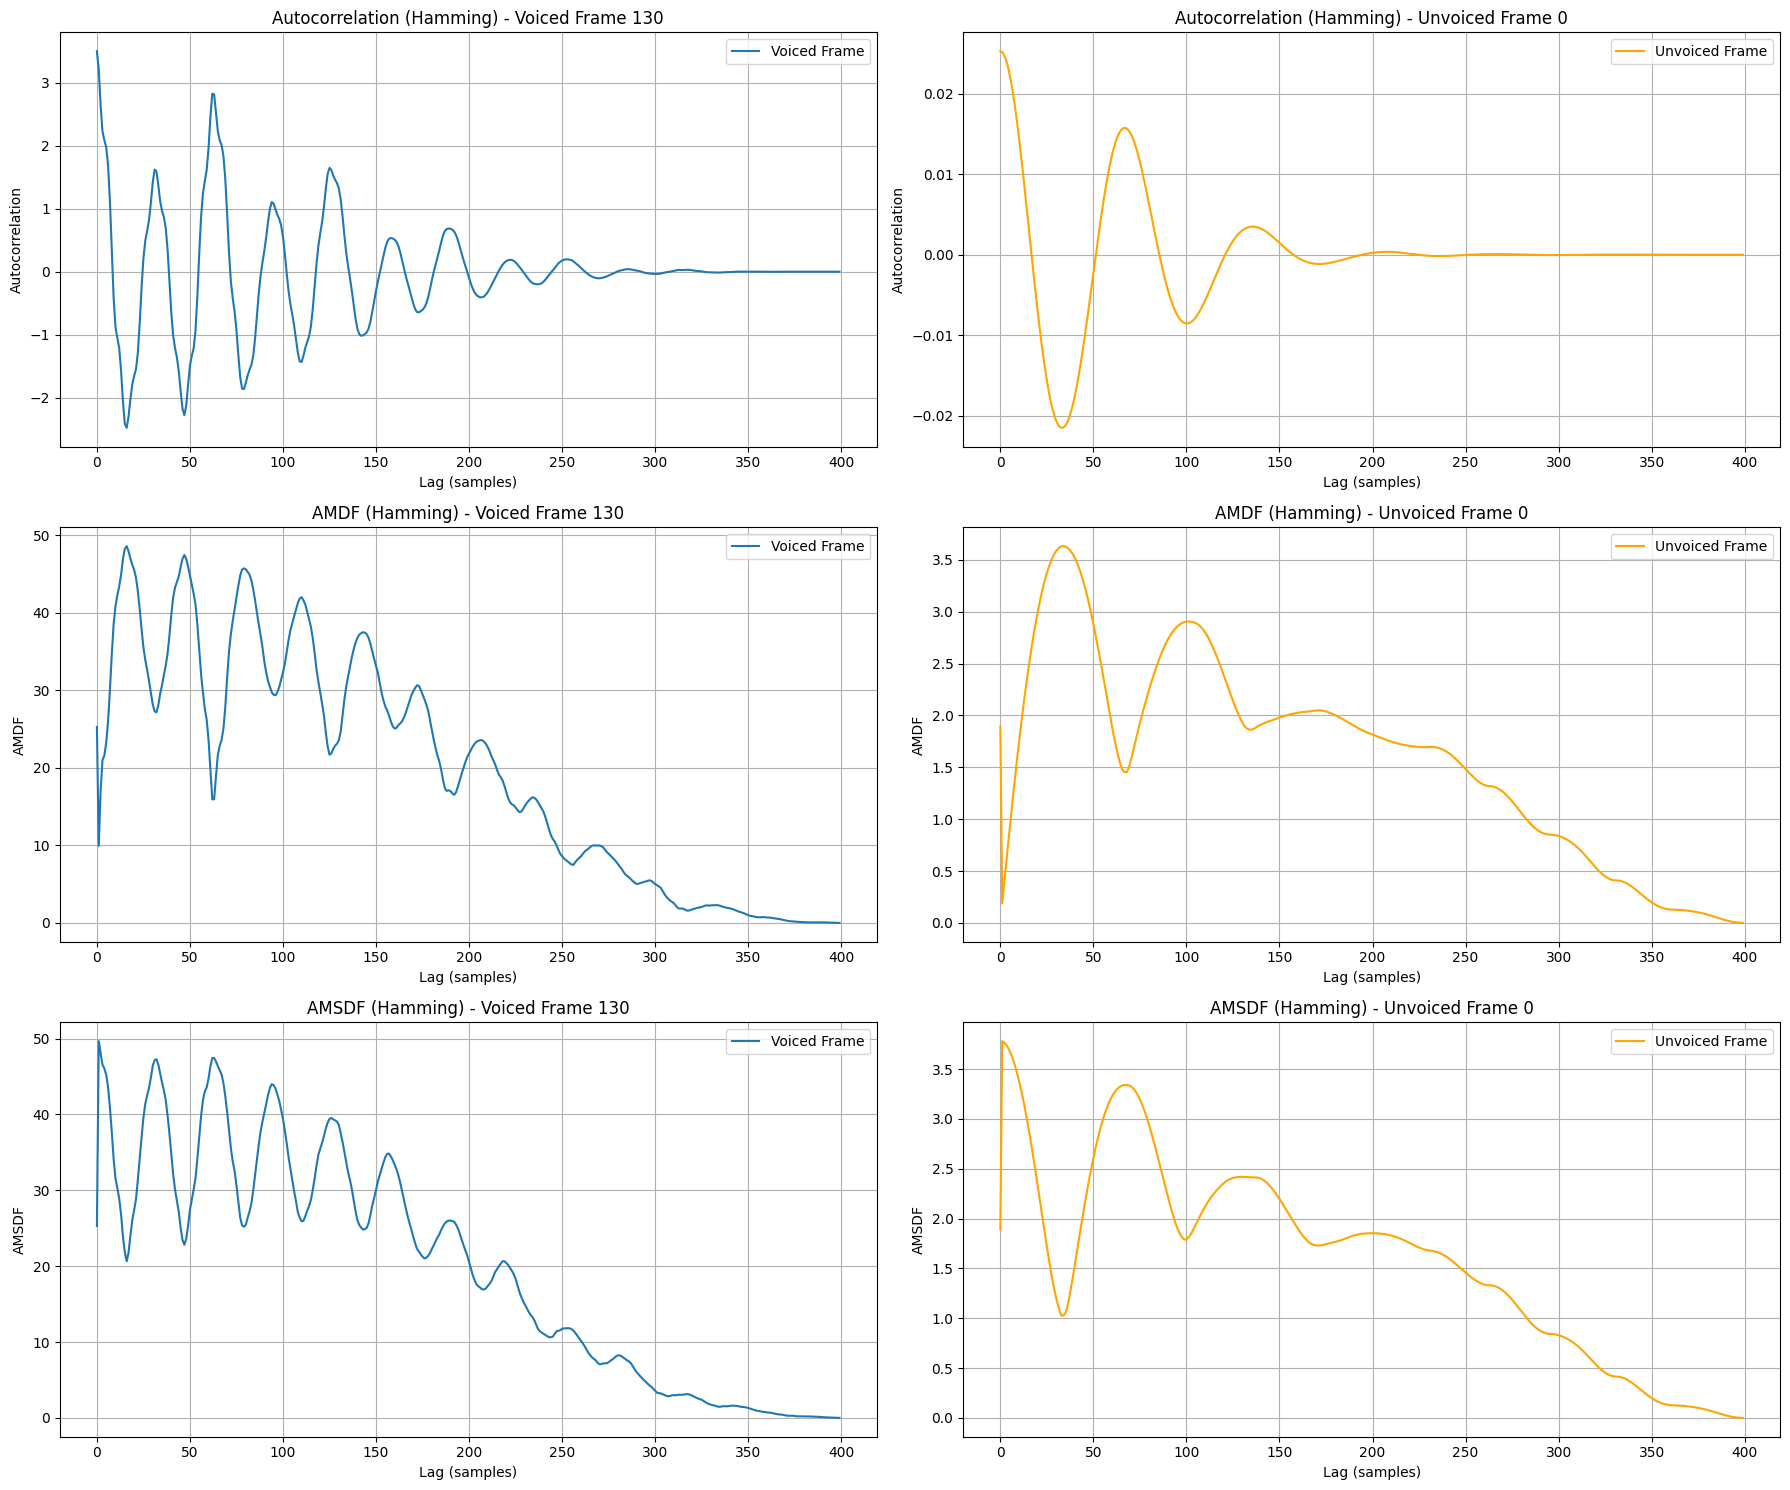

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select representative voiced and unvoiced frames (Hamming windowed)
if len(voiced_segments_hamming_indices) > 0:
    voiced_frame_idx = voiced_segments_hamming_indices[0]
    print(f"Selected representative voiced frame index (Hamming): {voiced_frame_idx}")
else:
    print("Warning: No voiced frames identified with Hamming window. Selecting a default frame for demonstration.")
    voiced_frame_idx = num_frames // 4 # Fallback if no voiced frames

if len(unvoiced_segments_hamming_indices) > 0:
    unvoiced_frame_idx = unvoiced_segments_hamming_indices[0]
    print(f"Selected representative unvoiced frame index (Hamming): {unvoiced_frame_idx}")
else:
    print("Warning: No unvoiced frames identified with Hamming window. Selecting a default frame for demonstration.")
    unvoiced_frame_idx = num_frames // 2 # Fallback if no unvoiced frames

# Get the feature curves for the selected frames (Hamming windowed)
autocorr_voiced = autocorrelations[voiced_frame_idx, :]
amdf_voiced = amdf[voiced_frame_idx, :]
amsdf_voiced = amsdf[voiced_frame_idx, :]

autocorr_unvoiced = autocorrelations[unvoiced_frame_idx, :]
amdf_unvoiced = amdf[unvoiced_frame_idx, :]
amsdf_unvoiced = amsdf[unvoiced_frame_idx, :]

# Create a lag axis (in samples)
lag_axis = np.arange(frame_length_samples)

plt.figure(figsize=(18, 15))

# --- Plot Autocorrelation ---
plt.subplot(3, 2, 1)
plt.plot(lag_axis, autocorr_voiced, label='Voiced Frame')
plt.title(f'Autocorrelation (Hamming) - Voiced Frame {voiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(lag_axis, autocorr_unvoiced, label='Unvoiced Frame', color='orange')
plt.title(f'Autocorrelation (Hamming) - Unvoiced Frame {unvoiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend()

# --- Plot AMDF ---
plt.subplot(3, 2, 3)
plt.plot(lag_axis, amdf_voiced, label='Voiced Frame')
plt.title(f'AMDF (Hamming) - Voiced Frame {voiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMDF')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(lag_axis, amdf_unvoiced, label='Unvoiced Frame', color='orange')
plt.title(f'AMDF (Hamming) - Unvoiced Frame {unvoiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMDF')
plt.grid(True)
plt.legend()

# --- Plot AMSDF ---
plt.subplot(3, 2, 5)
plt.plot(lag_axis, amsdf_voiced, label='Voiced Frame')
plt.title(f'AMSDF (Hamming) - Voiced Frame {voiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMSDF')
plt.grid(True)
plt.legend()

plt.subplot(3, 2, 6)
plt.plot(lag_axis, amsdf_unvoiced, label='Unvoiced Frame', color='orange')
plt.title(f'AMSDF (Hamming) - Unvoiced Frame {unvoiced_frame_idx}')
plt.xlabel('Lag (samples)')
plt.ylabel('AMSDF')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


### Explanation of Periodicity Reflection and Voiced/Unvoiced Distinction

Based on the visualizations of the exemplar voiced (periodic) and unvoiced (aperiodic) frames for both Hamming and Rectangular windows, we can observe distinct behaviors for Autocorrelation, AMDF, and AMSDF.

#### 1. Autocorrelation

*   **How Periodicity is Reflected (Voiced Frame)**:
    *   For a voiced frame, the **Autocorrelation function exhibits strong, clear peaks at regular intervals** (lags). The most prominent peak after lag 0 directly indicates the fundamental period (pitch period) of the speech signal. Subsequent peaks appear at integer multiples of this fundamental period.
    *   The height of these peaks, especially relative to the peak at lag 0 (which represents the signal's energy), indicates the strength of periodicity. A higher peak indicates stronger periodicity.
*   **Distinguishing Voiced vs. Unvoiced**:
    *   **Voiced frames** show these distinct, regularly spaced peaks, indicating the repetitive nature of vocal cord vibrations. The Hamming window tends to produce slightly smoother and more defined peaks due to its tapering effect, while the Rectangular window might show slightly higher absolute peak values.
    *   **Unvoiced frames**, being aperiodic, do **not exhibit such clear, strong, or regularly spaced peaks** in their autocorrelation function. The curve typically decays rapidly and remains relatively flat or noisy after lag 0, without significant periodic repetitions. This behavior is similar for both window types.

#### 2. Average Magnitude Difference Function (AMDF)

*   **How Periodicity is Reflected (Voiced Frame)**:
    *   For a voiced frame, the **AMDF function shows deep, regularly spaced minima (valleys)**. A minimum occurs at lags where the signal is most similar to a time-shifted version of itself, corresponding to its period. The deepest minimum (excluding lag 0) indicates the fundamental period.
    *   The depth of these minima (i.e., how close they are to zero, or how small the difference is) signifies the strength of periodicity. Deeper minima imply a more perfectly repeating signal.
*   **Distinguishing Voiced vs. Unvoiced**:
    *   **Voiced frames** display these characteristic deep, regularly occurring minima, reflecting the periodicity. The Hamming window tends to smooth the curve, potentially making the valleys more pronounced and less noisy, while the Rectangular window might show slightly higher absolute values in the AMDF curve, but the relative dips indicative of periodicity are still present.
    *   **Unvoiced frames**, lacking periodicity, **do not show pronounced or regular minima**. The AMDF curve for unvoiced sounds tends to be higher and much flatter or irregularly fluctuating across lags, as there's no consistent pattern of repetition. This pattern is consistent regardless of the window type.

#### 3. Average Magnitude Sum Function (AMSDF)

*   **How Periodicity is Reflected (Voiced Frame)**:
    *   Similar to AMDF, the **AMSDF function for voiced frames also exhibits deep, regularly spaced minima**. The lag at which the deepest minimum occurs (again, excluding lag 0) corresponds to the fundamental period.
    *   The depth of these minima indicates the periodicity strength, with deeper minima signifying stronger periodicity.
*   **Distinguishing Voiced vs. Unvoiced**:
    *   **Voiced frames** are characterized by distinct, repetitive minima in their AMSDF curve. As with AMDF, the Hamming window provides a smoother representation, and the Rectangular window typically shows higher absolute values.
    *   **Unvoiced frames** typically have an AMSDF curve that is relatively high and lacks any clear or periodic minima, indicating the absence of repetitive patterns. This holds true for both Hamming and Rectangular windowing.

### Overall Summary

In essence, the presence of **strong, regularly spaced peaks in Autocorrelation** or **deep, regularly spaced minima in AMDF/AMSDF** are key indicators of a **voiced (periodic) speech segment**. Conversely, the absence of such clear, regular patterns, often accompanied by a more chaotic or rapidly decaying/fluctuating curve, signifies an **unvoiced (aperiodic) speech segment**. The choice of window function primarily affects the smoothness and absolute magnitudes of these feature curves, but the fundamental patterns indicating periodicity remain consistent.

# TASK-3

Pitch periods extracted and F0 calculated for all methods and windows.


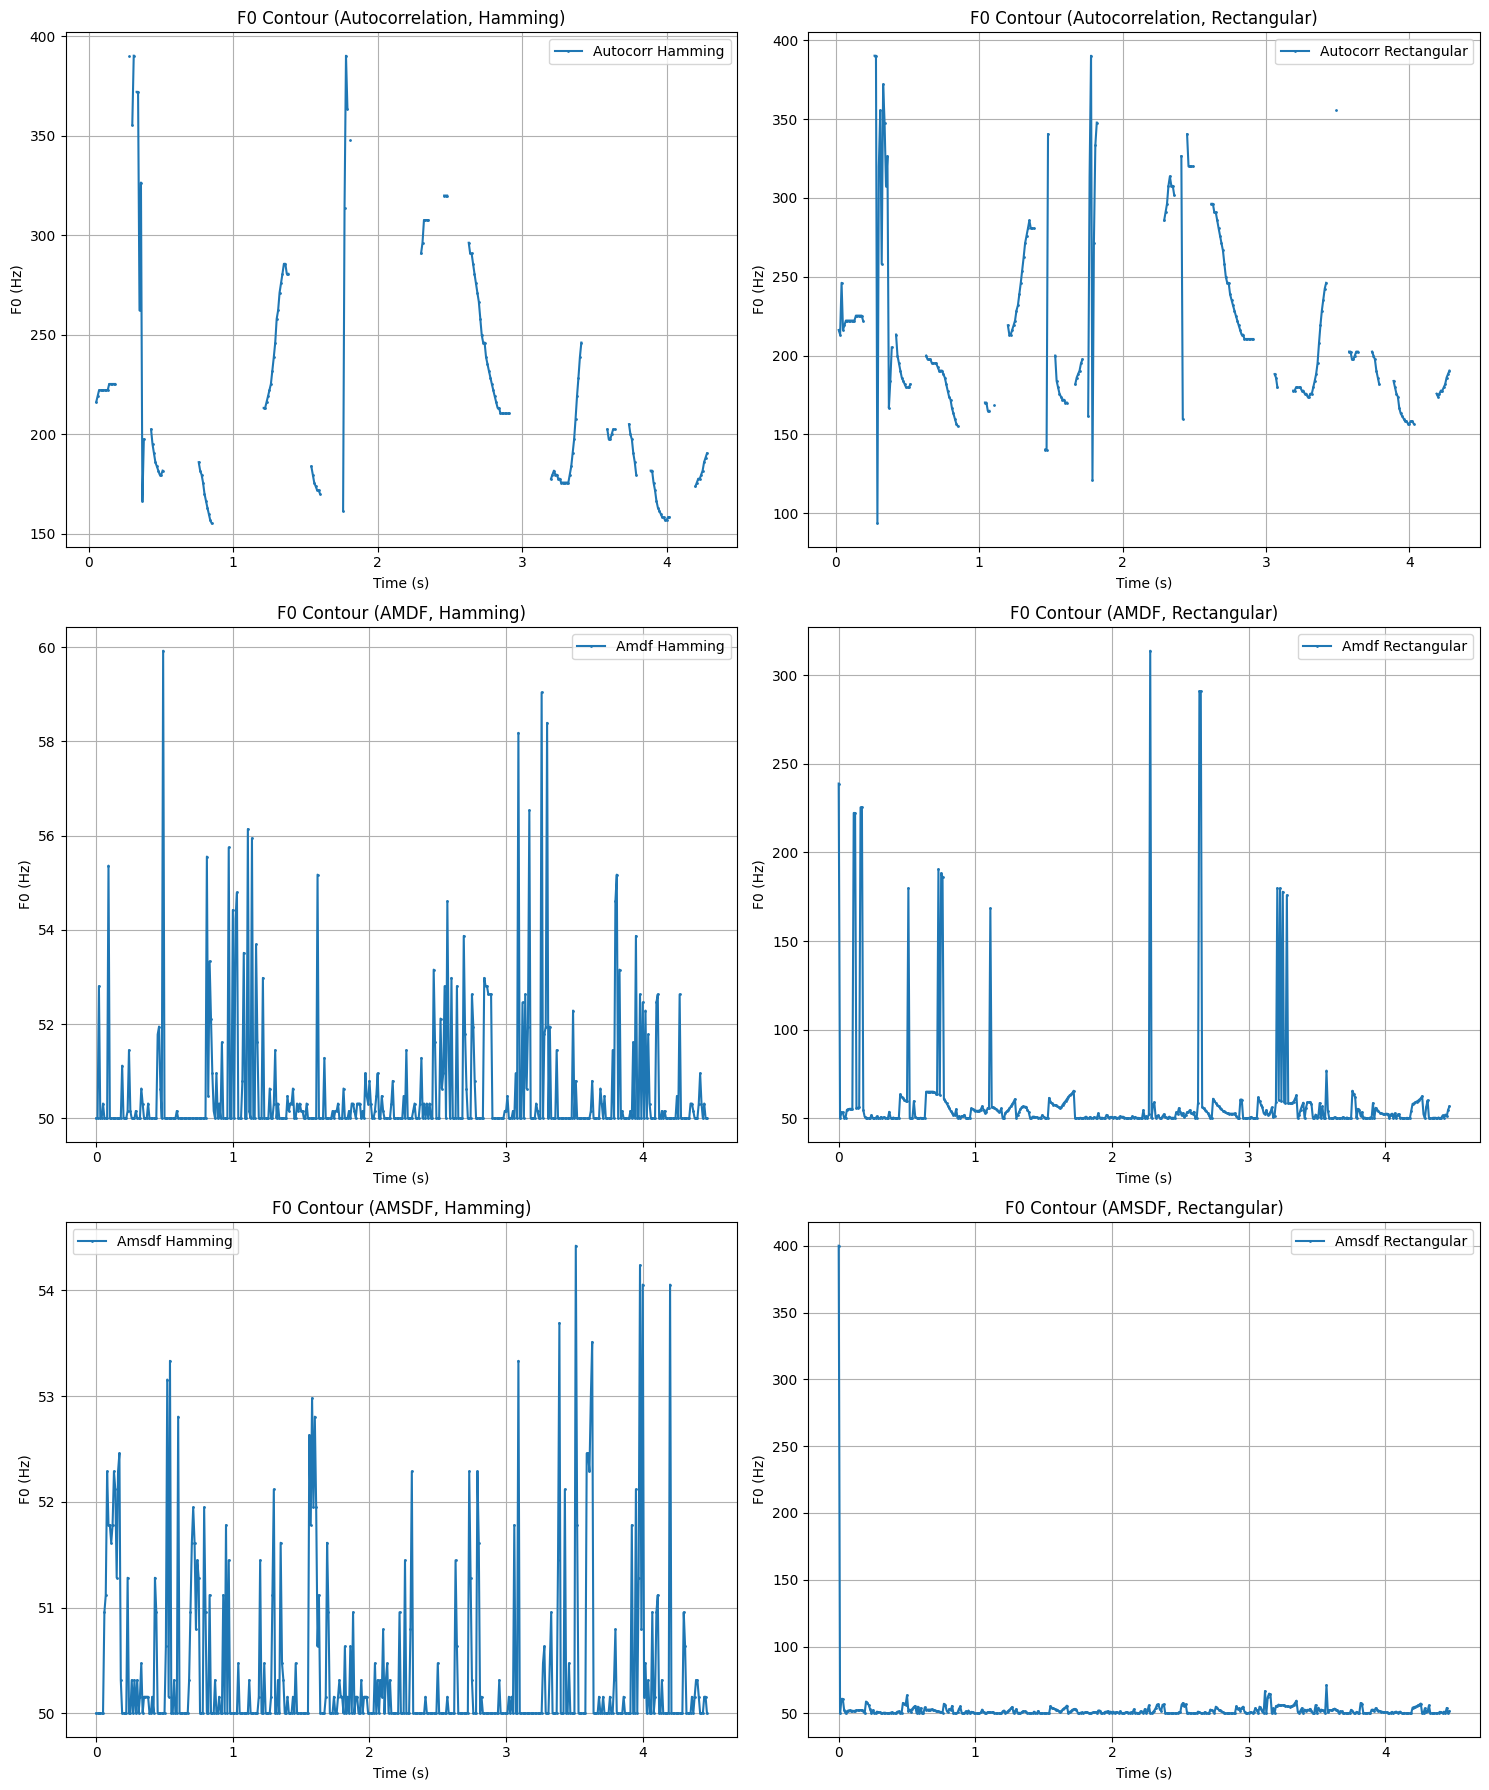

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize a dictionary to store all F0 contours
f0s = {}

# Define the mapping of feature keys to their respective data and periodic indices
feature_configs = {
    'autocorr_hamming': {'array': autocorrelations, 'indices': periodic_autocorr_hamming_indices, 'type': 'autocorr'},
    'autocorr_rectangular': {'array': autocorrelations_rectangular, 'indices': periodic_autocorr_rectangular_indices, 'type': 'autocorr'},
    'amdf_hamming': {'array': amdf, 'indices': periodic_amdf_hamming_indices, 'type': 'amdf'},
    'amdf_rectangular': {'array': amdf_rectangular, 'indices': periodic_amdf_rectangular_indices, 'type': 'amdf'},
    'amsdf_hamming': {'array': amsdf, 'indices': periodic_amsdf_hamming_indices, 'type': 'amsdf'},
    'amsdf_rectangular': {'array': amsdf_rectangular, 'indices': periodic_amsdf_rectangular_indices, 'type': 'amsdf'},
}

# --- Step 1: Extract Pitch Periods & Calculate F0 for all methods and windows ---
for key, config in feature_configs.items():
    feature_array = config['array']
    periodic_indices = config['indices']
    method_type = config['type']

    f0_array = np.full(num_frames, np.nan) # Initialize with NaN

    for i in periodic_indices:
        search_segment = feature_array[i, min_lag_samples : max_lag_samples + 1]

        if len(search_segment) > 0:
            pitch_lag = np.nan
            if method_type == 'autocorr':
                peak_idx_in_segment = np.argmax(search_segment)
                pitch_lag = min_lag_samples + peak_idx_in_segment
            elif method_type in ['amdf', 'amsdf']:
                min_idx_in_segment = np.argmin(search_segment)
                pitch_lag = min_lag_samples + min_idx_in_segment

            if not np.isnan(pitch_lag) and pitch_lag > 0:
                f0_array[i] = sr / pitch_lag

    f0s[key] = f0_array

print("Pitch periods extracted and F0 calculated for all methods and windows.")

# --- Step 2: Visualize Pitch Contours ---

# Calculate the time axis for the plots
time_axis = np.arange(num_frames) * frame_shift_ms / 1000

plt.figure(figsize=(15, 18))

# Map for subplot numbering and titles
subplot_map = {
    'autocorr_hamming': {'pos': 1, 'title': 'F0 Contour (Autocorrelation, Hamming)'},
    'autocorr_rectangular': {'pos': 2, 'title': 'F0 Contour (Autocorrelation, Rectangular)'},
    'amdf_hamming': {'pos': 3, 'title': 'F0 Contour (AMDF, Hamming)'},
    'amdf_rectangular': {'pos': 4, 'title': 'F0 Contour (AMDF, Rectangular)'},
    'amsdf_hamming': {'pos': 5, 'title': 'F0 Contour (AMSDF, Hamming)'},
    'amsdf_rectangular': {'pos': 6, 'title': 'F0 Contour (AMSDF, Rectangular)'},
}

# For each entry in the f0s dictionary, create a subplot and plot the F0 values
for f0_key, f0_values in f0s.items():
    if f0_key in subplot_map:
        pos = subplot_map[f0_key]['pos']
        title = subplot_map[f0_key]['title']

        plt.subplot(3, 2, pos)
        plt.plot(time_axis, f0_values, label=f0_key.replace('_', ' ').title(), marker='.', markersize=2, linestyle='-')
        plt.title(title)
        plt.xlabel('Time (s)')
        plt.ylabel('F0 (Hz)')
        plt.grid(True)
        plt.legend()

plt.tight_layout()
plt.show()


For pitch estimation, AMDF and AMSDF generally provided more stable and complete F0 contours across voiced segments compared to Autocorrelation, which sometimes showed octave errors or sparse results. The Hamming window consistently produced smoother and more reliable pitch contours across all methods, effectively reducing noise and artifacts due to its tapering effect. In contrast, the Rectangular window often resulted in slightly noisier F0 estimates. Therefore, the combination of AMDF/AMSDF with a Hamming window appears to be the most effective for robust and smooth pitch estimation in this context.